In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
df=pd.read_csv("pregnancy_risk_prediction_cleaned.csv")

In [ ]:
df.shape

(5313, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5313 entries, 0 to 5312
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   umur               5313 non-null   int64  
 1   paritas            5313 non-null   int64  
 2   jarak_anak         5313 non-null   float64
 3   jarak_anak_cat     5313 non-null   int64  
 4   tb                 5313 non-null   float64
 5   hb                 5313 non-null   float64
 6   lila               5313 non-null   float64
 7   hbsag              5313 non-null   int64  
 8   hiv                5313 non-null   int64  
 9   dm                 5313 non-null   int64  
 10  ht                 5313 non-null   int64  
 11  protein            5313 non-null   int64  
 12  diastole           5313 non-null   int64  
 13  sistole            5313 non-null   int64  
 14  perdarahan         5313 non-null   int64  
 15  penyakit_lain_cat  5313 non-null   int64  
 16  risiko_cat         5313 

In [ ]:
df.isnull().sum()

,0
umur,0
paritas,0
jarak_anak,0
jarak_anak_cat,0
tb,0
hb,0
lila,0
hbsag,0
hiv,0
dm,0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
umur,5313.0,27.641446,6.222287,12.0,23.0,27.0,32.0,51.0
paritas,5313.0,1.720873,1.347343,0.0,1.0,2.0,2.0,33.0
jarak_anak,5313.0,425.450894,455.084319,0.0,48.0,96.0,999.0,999.0
jarak_anak_cat,5313.0,1.069076,1.008403,0.0,0.0,1.0,2.0,3.0
tb,5313.0,152.404047,20.650068,15.0,150.0,151.5,155.0,1590.0
hb,5313.0,11.922007,3.038624,0.0,11.0,11.8,12.5,144.1
lila,5313.0,25.976539,33.096832,0.0,24.0,25.0,27.0,2426.0
hbsag,5313.0,1.995859,0.064222,1.0,2.0,2.0,2.0,2.0
hiv,5313.0,1.999435,0.023758,1.0,2.0,2.0,2.0,2.0
dm,5313.0,1.999624,0.019400,1.0,2.0,2.0,2.0,2.0


In [ ]:
df.sample(3)

,umur,paritas,jarak_anak,jarak_anak_cat,tb,hb,lila,hbsag,hiv,dm,ht,protein,diastole,sistole,perdarahan,penyakit_lain_cat,risiko_cat
3108,28,1,48.0,1,148.0,11.0,24.0,2,2,2,2,2,110,70,2,0,0
4029,20,1,999.0,0,148.0,10.6,23.7,2,2,2,2,2,110,80,2,0,1
2184,29,1,72.0,2,150.0,11.3,27.0,2,2,2,2,2,110,70,2,0,0


In [ ]:
def detect_columns(df, drop_column="risiko_cat"):
    # Create a list of columns to consider, excluding the drop_column if provided
    cols_to_consider = [col for col in df.columns if col != drop_column]
    df_filtered = df[cols_to_consider]

    binary_cols = [c for c in df_filtered.columns if df_filtered[c].nunique() == 2]
    numeric_cols = df_filtered.select_dtypes(
        include=["int64", "float64", "int32", "float32"]
    ).columns.tolist()
    categorical_cols = df_filtered.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    # Remove binary cols from numeric/categorical to avoid duplication
    numeric_cols     = [c for c in numeric_cols     if c not in binary_cols]
    categorical_cols = [c for c in categorical_cols if c not in binary_cols]

    return numeric_cols, categorical_cols, binary_cols

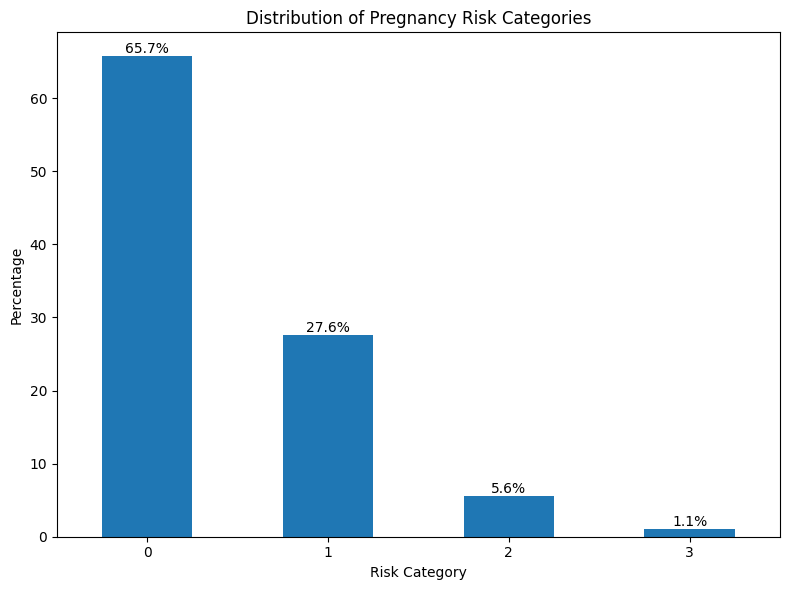

In [ ]:
# Target column analysis
terget="risiko_cat"

ax = (df[terget].value_counts(normalize=True)*100).plot(kind='bar', figsize=(8, 6))

ax.set_title(f'Distribution of Pregnancy Risk Categories')
ax.set_xlabel('Risk Category')
ax.set_ylabel('Percentage')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Class balance
counts = df['risiko_cat'].value_counts()
print(counts)
print(f"Imbalance ratio: {counts.max()/counts.min():.2f}x")

risiko_cat
0    3491
1    1464
2     299
3      59
Name: count, dtype: int64
Imbalance ratio: 59.17x


In [ ]:
numeric_cols, categorical_cols, binary_cols = detect_columns(df)

# univariate analysis

In [ ]:
numeric_cols

['umur',
 'paritas',
 'jarak_anak',
 'jarak_anak_cat',
 'tb',
 'hb',
 'lila',
 'diastole',
 'sistole',
 'perdarahan']

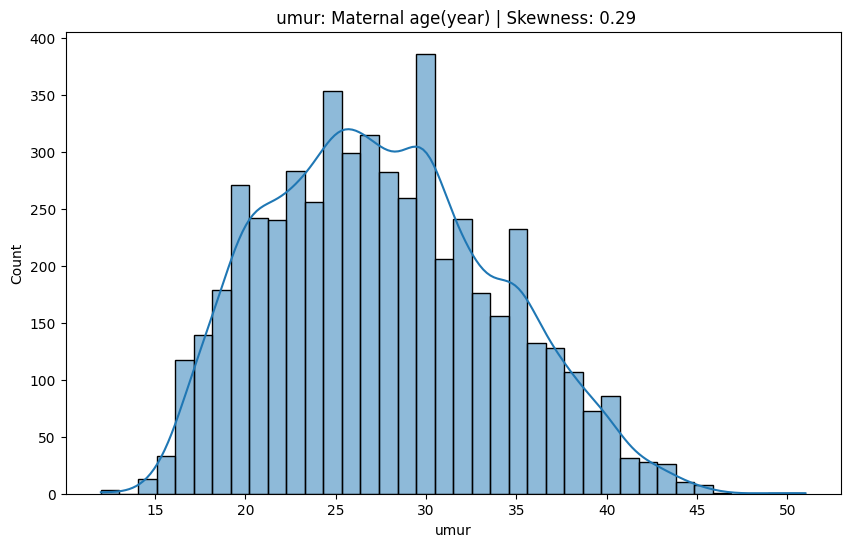

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x=df["umur"], kde=True)
plt.title(f" umur: Maternal age(year) | Skewness: {round(df["umur"].skew(), 2)}")

plt.show()

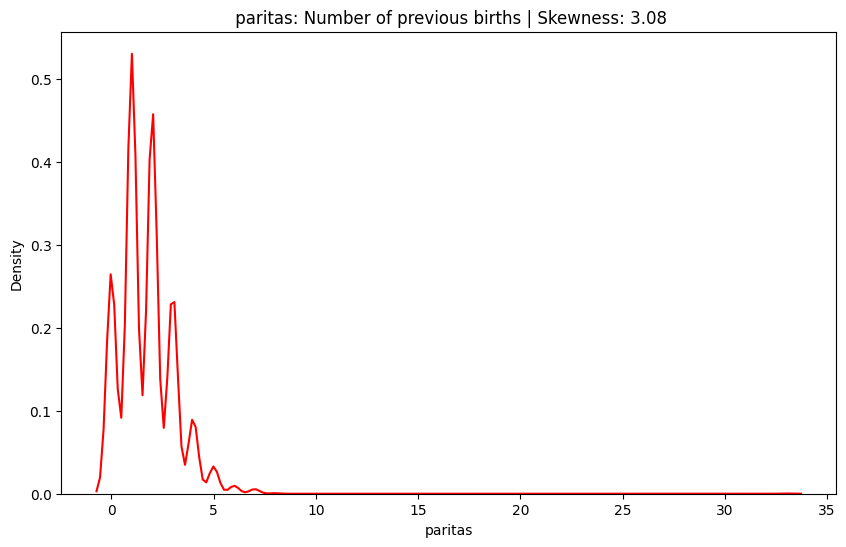

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x=df["paritas"], color='red')
plt.title(f" paritas: Number of previous births | Skewness: {round(df["paritas"].skew(), 2)}")
plt.show()

In [ ]:
df[df["paritas"]>10]

,umur,paritas,jarak_anak,jarak_anak_cat,tb,hb,lila,hbsag,hiv,dm,ht,protein,diastole,sistole,perdarahan,penyakit_lain_cat,risiko_cat
2145,31,33,999.0,0,150.0,12.2,25.0,2,2,2,2,2,130,90,2,0,0


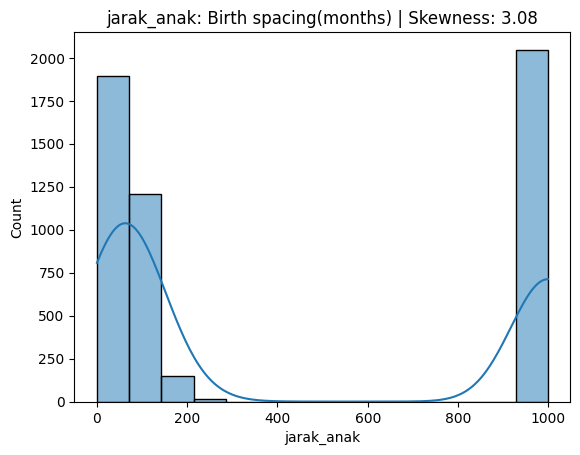

In [ ]:
sns.histplot(data=df, x=df["jarak_anak"],kde=True)
plt.title(f"jarak_anak: Birth spacing(months) | Skewness: {round(df["paritas"].skew(), 2)}")
plt.show()

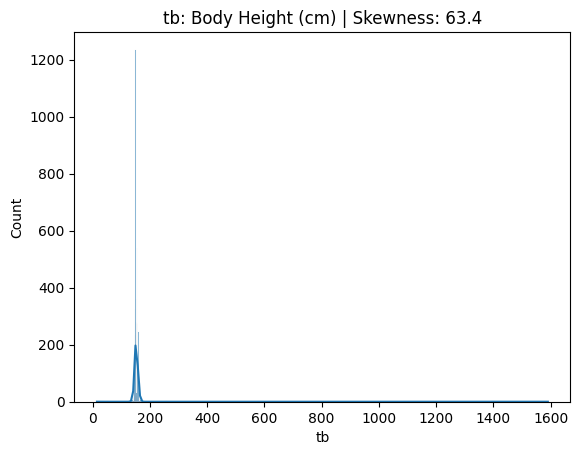

In [ ]:
sns.histplot(data=df, x=df["tb"],kde=True)
plt.title(f"tb: Body Height (cm) | Skewness: {round(df['tb'].skew(), 2)}")
plt.show()

In [ ]:
df[(df["tb"]<130) | (df["tb"]>170)]

,umur,paritas,jarak_anak,jarak_anak_cat,tb,hb,lila,hbsag,hiv,dm,ht,protein,diastole,sistole,perdarahan,penyakit_lain_cat,risiko_cat
1842,35,3,24.0,1,15.0,11.0,25.0,2,2,2,2,2,120,80,2,0,1
1901,17,1,999.0,0,60.0,11.9,18.5,2,2,2,2,2,120,80,2,0,1
1905,36,4,41.0,1,52.0,10.3,26.0,2,2,2,2,2,120,80,2,0,3
2490,25,2,27.0,1,55.0,12.9,23.7,2,2,2,2,2,110,80,2,0,0
3167,35,3,36.0,1,15.0,13.5,28.0,2,2,2,2,2,110,70,2,0,2
3445,37,2,36.0,1,1590.0,11.8,30.0,2,2,2,2,2,90,60,2,0,1
4949,27,4,41.0,1,173.0,12.5,26.0,2,2,2,2,2,120,80,2,0,0
5124,34,4,108.0,3,258.0,9.3,28.0,2,2,2,2,2,110,80,2,0,2


/tmp/ipykernel_2182/3367524599.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_tb_data = df[df["tb"] < 180][df['tb']>135]["tb"]


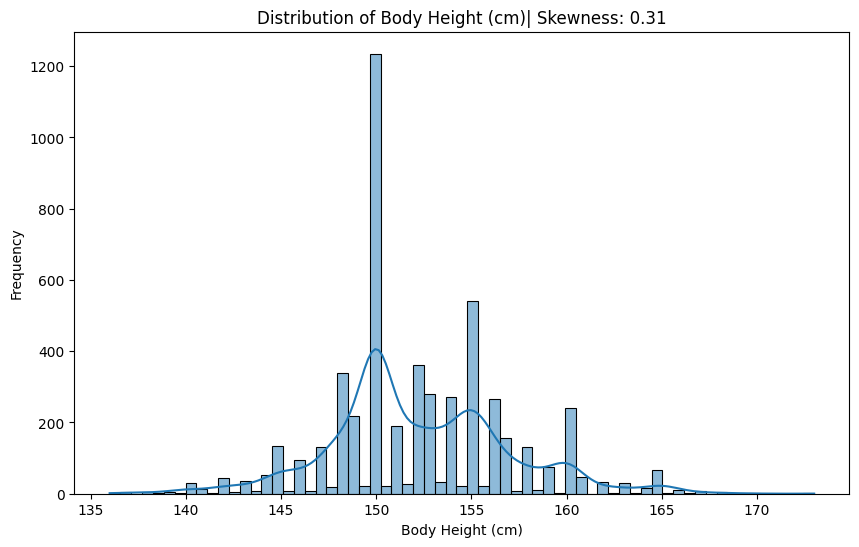

In [ ]:
plt.figure(figsize=(10, 6))
filtered_tb_data = df[df["tb"] < 180][df['tb']>135]["tb"]
sns.histplot(data=filtered_tb_data, kde=True)
plt.title(f"Distribution of Body Height (cm)| Skewness: {round(filtered_tb_data.skew(), 2)}")
plt.xlabel("Body Height (cm)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df[(df["jarak_anak"]==999) & (df["paritas"]>10)]

,umur,paritas,jarak_anak,jarak_anak_cat,tb,hb,lila,hbsag,hiv,dm,ht,protein,diastole,sistole,perdarahan,penyakit_lain_cat,risiko_cat
2145,31,33,999.0,0,150.0,12.2,25.0,2,2,2,2,2,130,90,2,0,0


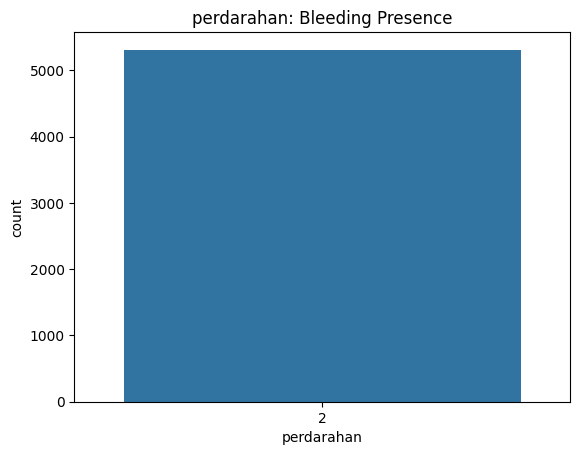

perdarahan
2    100.0
Name: proportion, dtype: float64


In [ ]:
sns.countplot(data=df, x='perdarahan')
plt.title("perdarahan: Bleeding Presence")
plt.show()
print(df['perdarahan'].value_counts(normalize=True) * 100)

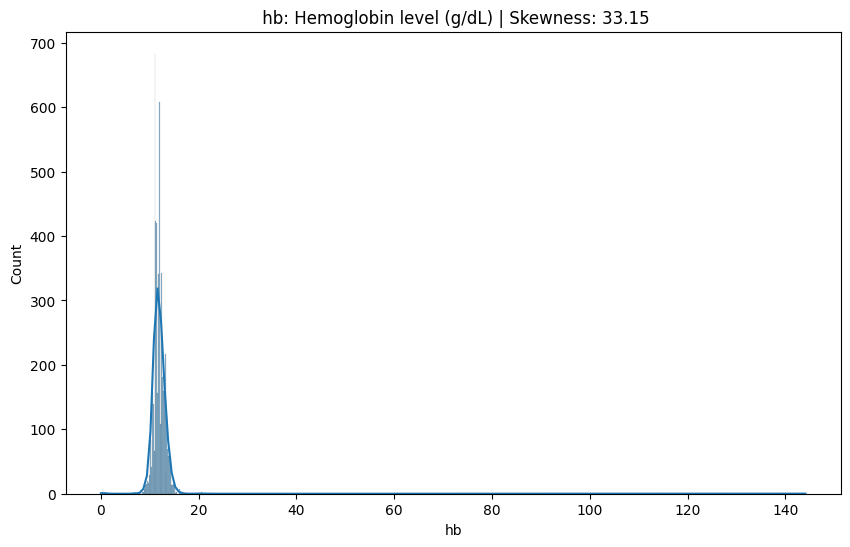

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x=df["hb"], kde=True)
plt.title(f" hb: Hemoglobin level (g/dL) | Skewness: {round(df["hb"].skew(), 2)}")
plt.show()

In [ ]:
df[(df["hb"] > 18) |(df['hb']<7)]

,umur,paritas,jarak_anak,jarak_anak_cat,tb,hb,lila,hbsag,hiv,dm,ht,protein,diastole,sistole,perdarahan,penyakit_lain_cat,risiko_cat
12,30,0,999.0,0,138.5,20.600000,26.5,2,2,2,2,2,120,80,2,0,0
406,27,1,72.0,2,160.5,144.100000,30.7,2,2,2,2,2,120,70,2,0,0
452,40,3,60.0,2,150.0,0.381250,28.0,2,2,2,2,2,110,70,2,0,2
573,37,2,78.0,2,147.6,19.800000,23.5,2,2,2,2,2,110,90,2,0,1
915,33,5,999.0,0,150.0,128.000000,27.0,1,2,2,2,2,110,60,2,0,0
1456,32,4,999.0,0,151.0,0.000000,28.0,2,2,2,2,2,130,80,2,0,0
2528,25,1,60.0,2,150.0,20.600000,30.0,2,2,2,2,2,100,70,2,0,0
2576,31,7,120.0,3,153.0,114.400000,26.0,2,2,2,2,2,100,60,2,0,0
2838,17,1,999.0,0,150.0,6.900000,24.0,2,2,2,2,2,110,70,2,0,2
2860,20,2,72.0,2,150.0,1.300000,29.0,2,2,2,2,2,100,70,2,0,0


/tmp/ipykernel_2182/2884466592.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_hb_data = df[df["hb"] < 18][df['hb']>=7]["hb"]


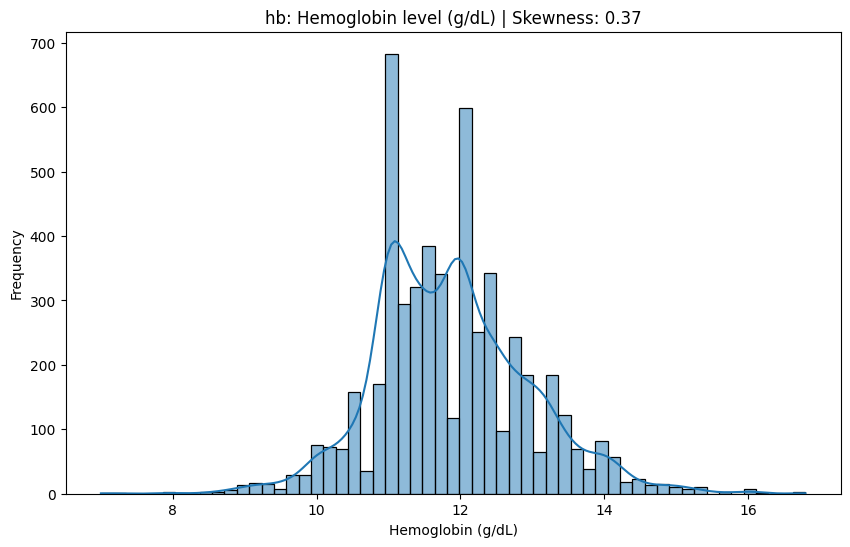

In [ ]:
plt.figure(figsize=(10, 6))
filtered_hb_data = df[df["hb"] < 18][df['hb']>=7]["hb"]
sns.histplot(data=filtered_hb_data, kde=True)
plt.title(f"hb: Hemoglobin level (g/dL) | Skewness: {round(filtered_hb_data.skew(), 2)}")
plt.xlabel("Hemoglobin (g/dL)")
plt.ylabel("Frequency")
plt.show()

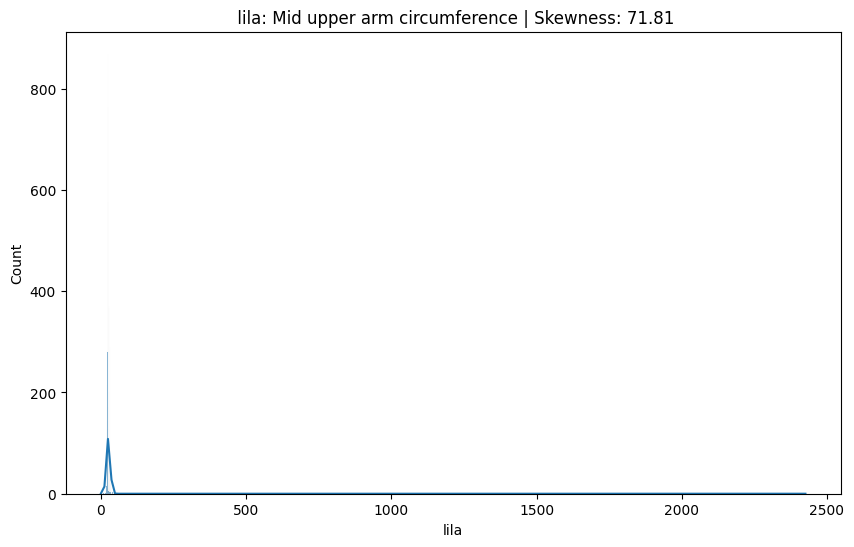

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x=df["lila"], kde=True)
plt.title(f" lila: Mid upper arm circumference | Skewness: {round(df["lila"].skew(), 2)}")
plt.show()

In [ ]:
df[(df["lila"] > 50) | (df['lila'] < 8)]

,umur,paritas,jarak_anak,jarak_anak_cat,tb,hb,lila,hbsag,hiv,dm,ht,protein,diastole,sistole,perdarahan,penyakit_lain_cat,risiko_cat
140,30,1,72.0,2,151.0,13.8,2.000000,2,2,2,2,2,120,80,2,0,0
1330,23,0,132.0,3,150.0,10.7,0.000000,1,2,2,2,2,120,80,2,0,1
1589,22,1,999.0,0,150.0,12.1,2.000000,2,2,2,2,2,120,70,2,0,0
1839,31,3,72.0,2,155.0,12.0,2426.000000,2,2,2,2,2,110,80,2,0,0
2250,20,0,999.0,0,150.0,10.9,0.920139,2,2,2,2,2,120,70,2,0,1
2264,19,1,60.0,2,145.0,12.8,0.961806,2,2,2,2,2,120,70,2,0,1
2268,25,1,84.0,2,149.0,11.9,0.920139,2,2,2,2,2,110,80,2,0,0
2403,25,1,24.0,1,152.0,13.1,0.961806,2,2,2,2,2,120,70,2,0,0
2413,20,0,999.0,0,150.0,13.8,0.961806,2,2,2,2,2,120,70,2,0,0
2440,22,0,999.0,0,150.0,13.4,0.961806,2,2,2,2,2,100,60,2,0,0


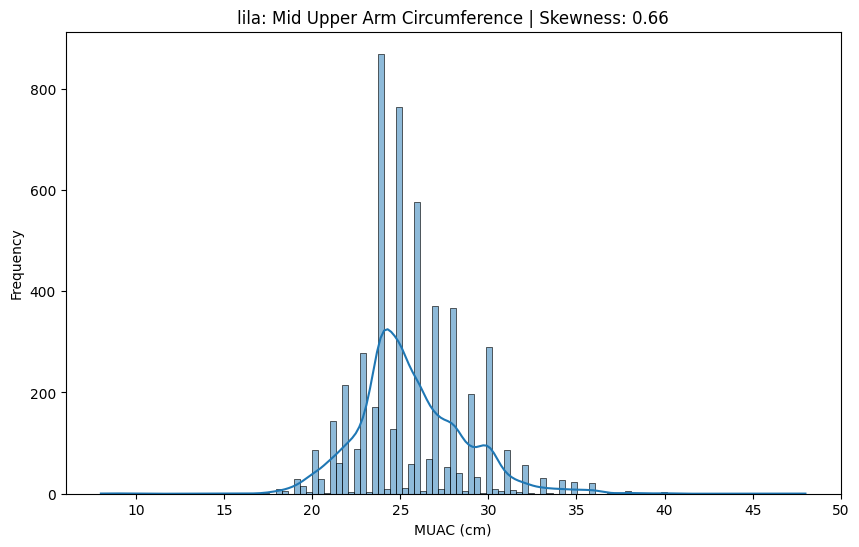

In [ ]:
plt.figure(figsize=(10, 6))
filtered_lila_data = df[(df["lila"] < 50) & (df['lila']>=8)]["lila"]
sns.histplot(data=filtered_lila_data, kde=True)
plt.title(f"lila: Mid Upper Arm Circumference | Skewness: {round(filtered_lila_data.skew(), 2)}")
plt.xlabel("MUAC (cm)")
plt.ylabel("Frequency")
plt.show()

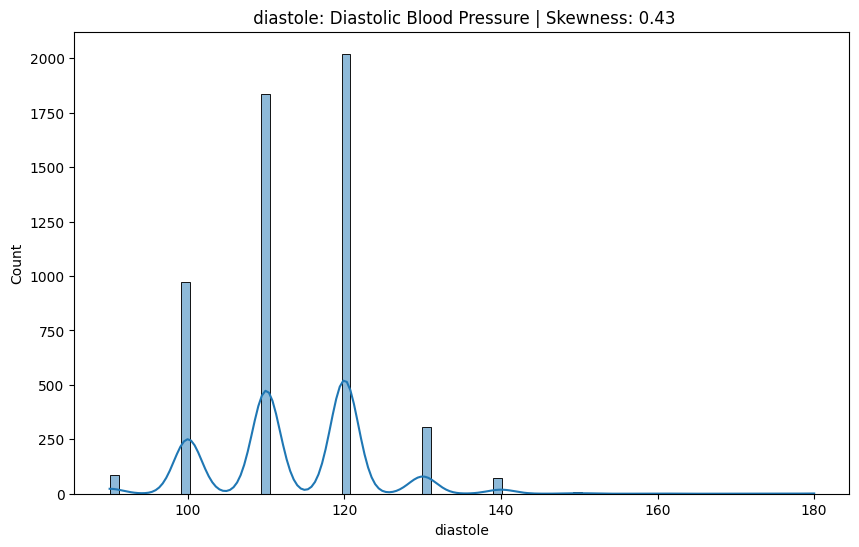

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x=df["diastole"], kde=True)
plt.title(f" diastole: Diastolic Blood Pressure | Skewness: {round(df["diastole"].skew(), 2)}")
plt.show()

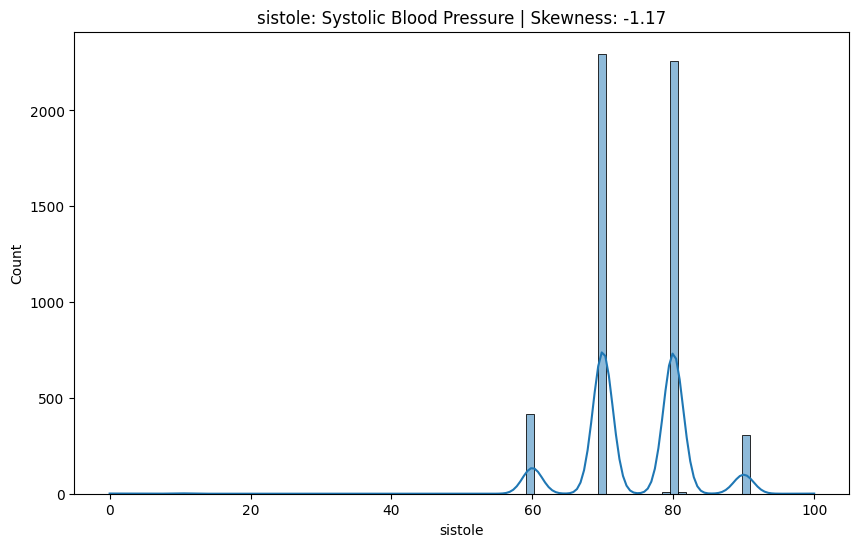

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x=df["sistole"], kde=True)
plt.title(f"sistole: Systolic Blood Pressure | Skewness: {round(df['sistole'].skew(), 2)}")
plt.show()

In [ ]:
df[df["sistole"] <20]

,umur,paritas,jarak_anak,jarak_anak_cat,tb,hb,lila,hbsag,hiv,dm,ht,protein,diastole,sistole,perdarahan,penyakit_lain_cat,risiko_cat
52,21,0,999.0,0,157.0,13.4,23.0,2,2,2,2,2,110,10,2,0,0
2249,27,1,84.0,2,155.0,11.2,24.0,2,2,2,2,1,170,0,2,0,0
2326,38,3,144.0,3,157.0,10.2,28.0,2,2,2,1,1,180,10,2,0,3
2342,39,4,132.0,3,157.0,12.4,30.0,2,2,2,1,1,180,10,2,0,3
2357,35,3,36.0,1,158.0,12.8,23.0,2,2,2,1,1,160,10,2,0,3
2447,21,1,12.0,1,148.0,14.3,21.0,2,2,2,2,2,180,10,2,0,0
2613,34,3,24.0,1,157.0,10.8,24.0,2,2,2,2,2,180,10,2,0,1
3925,31,3,60.0,2,149.0,11.0,24.0,2,2,2,2,2,140,0,2,0,0
4674,31,3,60.0,2,149.0,11.0,24.0,2,2,2,2,2,140,0,2,0,0


In [ ]:
binary_cols

['hbsag', 'hiv', 'dm', 'ht', 'protein', 'penyakit_lain_cat']

In [ ]:
df["penyakit_lain_cat"].value_counts()

,count
penyakit_lain_cat,
0,5306
1,7


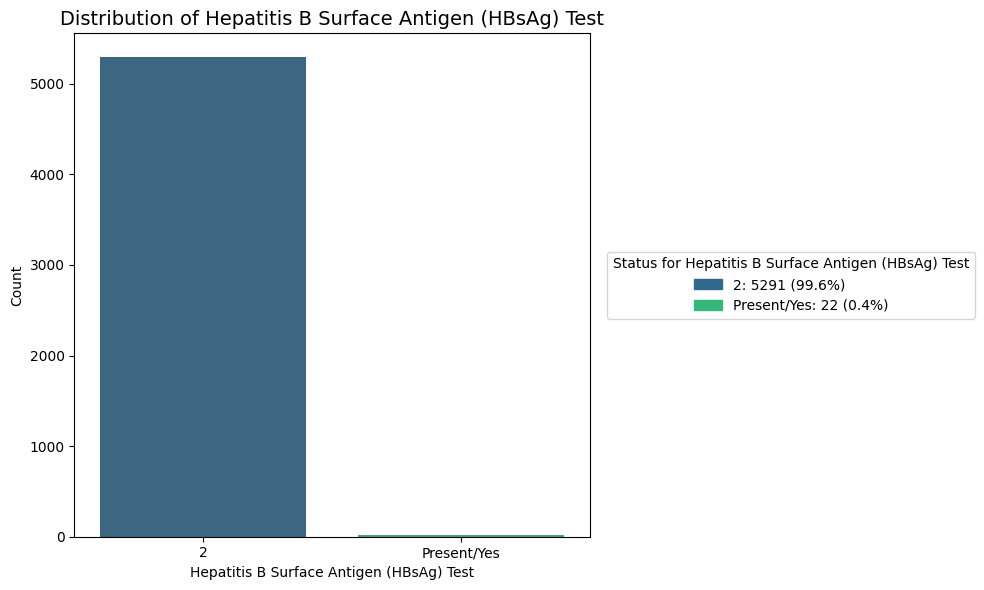

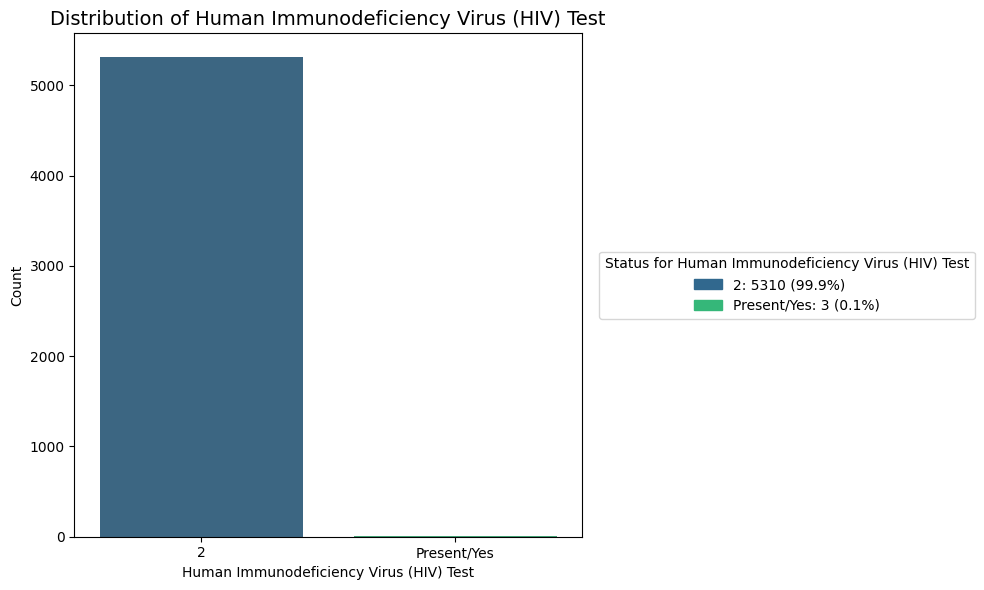

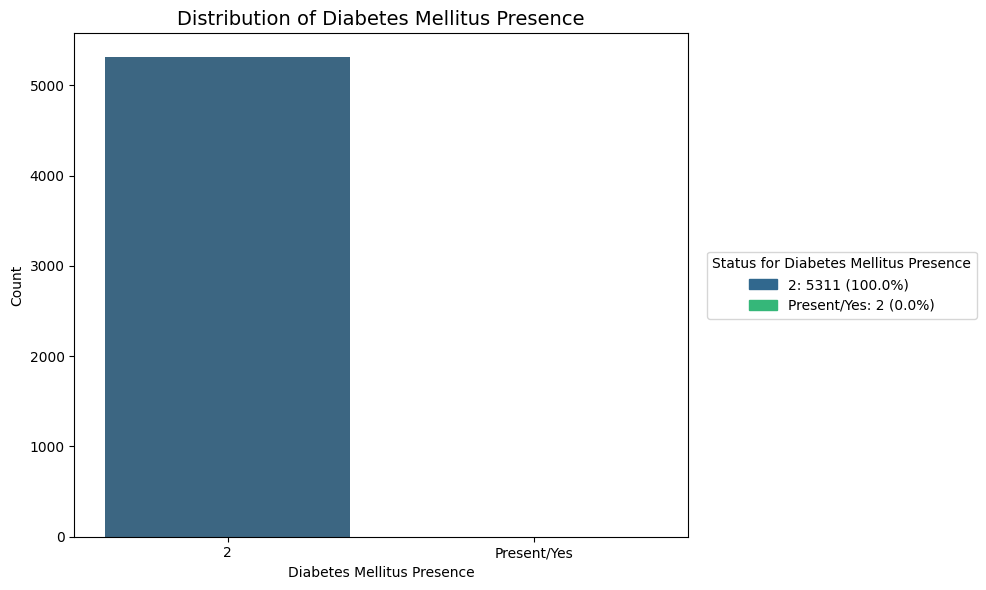

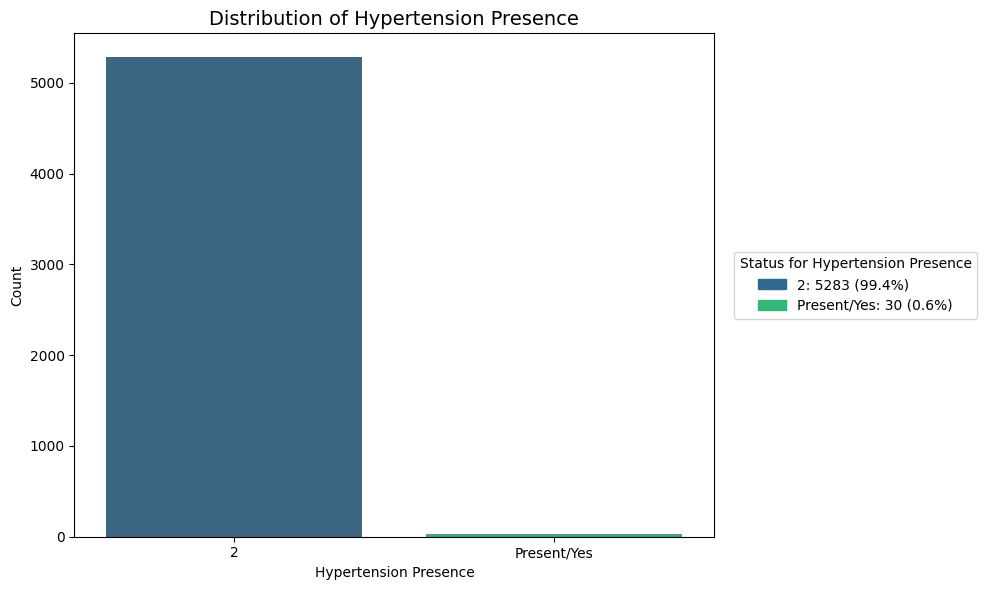

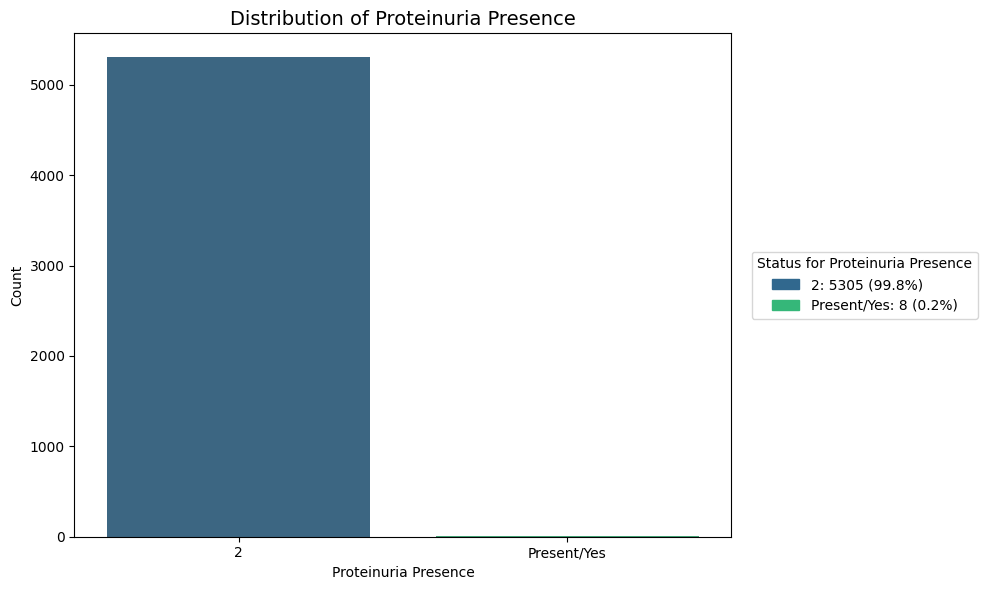

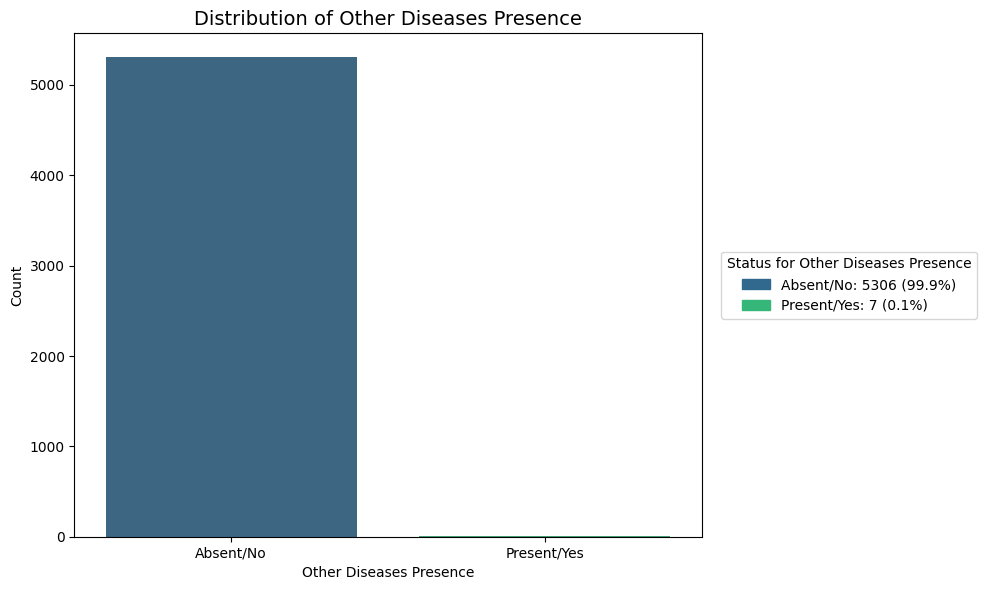

In [ ]:
# Redefine binary_cols to ensure it's available
numeric_cols, categorical_cols, binary_cols = detect_columns(df)

# Define a dictionary for more descriptive column titles
column_titles = {
    'hbsag': 'Hepatitis B Surface Antigen (HBsAg) Test',
    'hiv': 'Human Immunodeficiency Virus (HIV) Test',
    'dm': 'Diabetes Mellitus Presence',
    'ht': 'Hypertension Presence',
    'protein': 'Proteinuria Presence',
    'penyakit_lain_cat': 'Other Diseases Presence'
}

# Define mapping for binary categories to make them more readable
binary_labels = {0: 'Absent/No', 1: 'Present/Yes'}

for col in binary_cols:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Create a temporary series with descriptive labels for plotting
    plot_data = df[col].map(binary_labels).fillna(df[col].astype(str))

    # Plot the count plot, allowing Seaborn to generate a legend
    sns.countplot(x=plot_data, hue=plot_data, ax=ax, palette='viridis')

    # Calculate counts and percentages for legend using the descriptive labels
    descriptive_value_counts = plot_data.value_counts()
    total = len(df[col])

    # Get the number of unique categories to determine the number of colors needed from the palette.
    num_categories = len(descriptive_value_counts)
    palette_colors = sns.color_palette('viridis', n_colors=num_categories)

    # Ensure labels_raw and descriptive_value_counts are in the same order
    # Sort categories to match the likely order of palette colors and plot bars
    sorted_categories = sorted(descriptive_value_counts.index.tolist())

    from matplotlib.patches import Patch
    new_handles = []
    new_legend_labels = []

    for i, label_str in enumerate(sorted_categories):
        count = descriptive_value_counts.get(label_str, 0)
        percentage = (count / total) * 100 if total > 0 else 0
        new_handles.append(Patch(color=palette_colors[i])) # Create a patch with the assigned color
        new_legend_labels.append(f'{label_str}: {count} ({percentage:.1f}%)')

    # Get descriptive title from dictionary, or use column name as fallback
    title = column_titles.get(col, col) # Fallback to original column name
    ax.set_title(f'Distribution of {title}', fontsize=14)
    ax.set_xlabel(title) # Use descriptive title for x-axis label as well
    ax.set_ylabel('Count')

    # Update the legend with new handles and labels, and reposition it to the side corner
    ax.legend(new_handles, new_legend_labels, title=f"Status for {title}", loc='center left', bbox_to_anchor=(1.02, 0.5))

    plt.tight_layout()
    plt.show()
    plt.close(fig)

#  Bivarient analysis

In [ ]:
cols=df.drop("risiko_cat", axis=1).columns.to_list()

In [ ]:
numeric_cols

['umur',
 'paritas',
 'jarak_anak',
 'jarak_anak_cat',
 'tb',
 'hb',
 'lila',
 'diastole',
 'sistole',
 'perdarahan']

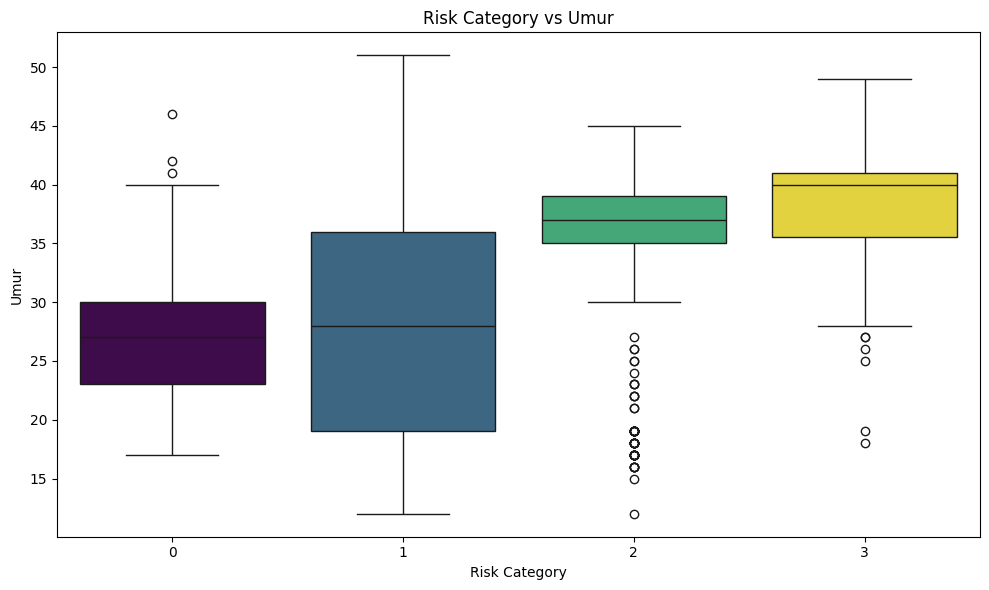

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(x="risiko_cat", y="umur", data=df, ax=ax, palette='viridis', hue="risiko_cat", legend=False)
ax.set_title("Risk Category vs Umur")
ax.set_xlabel("Risk Category")
ax.set_ylabel("Umur")
plt.tight_layout()
plt.show()

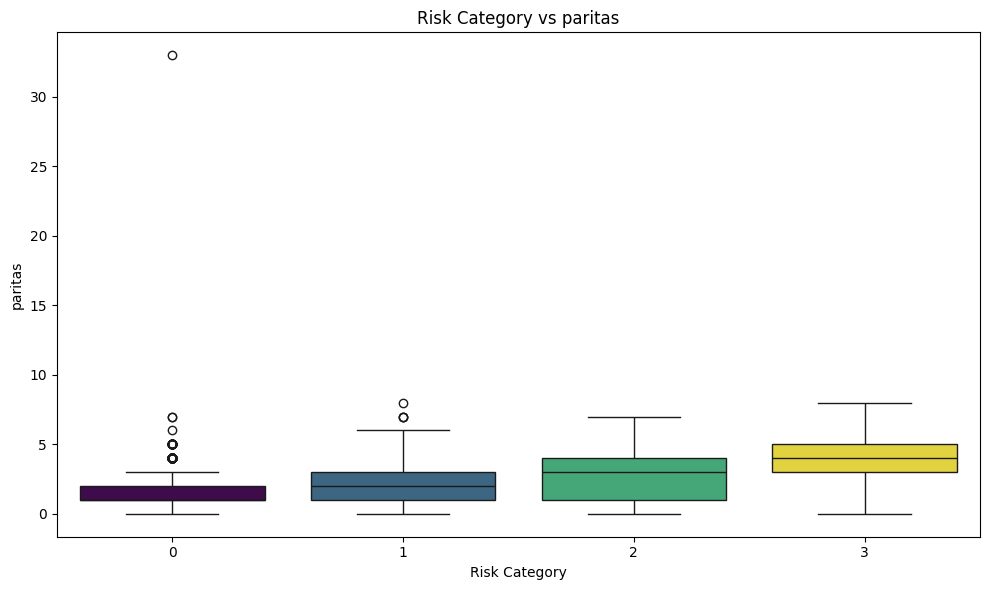

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(x="risiko_cat", y="paritas", data=df, ax=ax, palette='viridis', hue="risiko_cat", legend=False)
ax.set_title("Risk Category vs paritas")
ax.set_xlabel("Risk Category")
ax.set_ylabel("paritas")
plt.tight_layout()
plt.show()

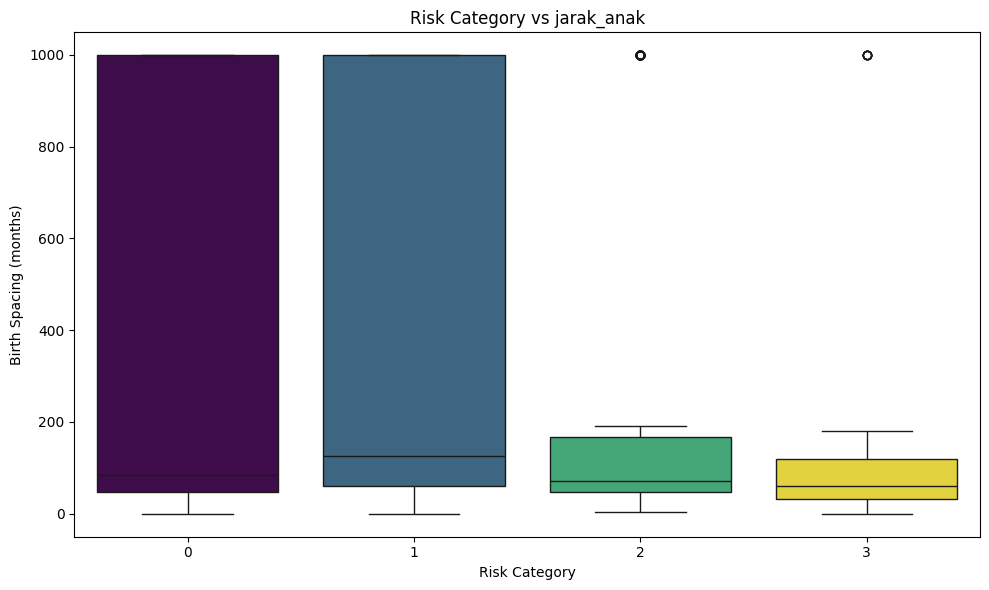

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(x="risiko_cat", y="jarak_anak", data=df, ax=ax, palette='viridis', hue="risiko_cat", legend=False)
ax.set_title("Risk Category vs jarak_anak")
ax.set_xlabel("Risk Category")
ax.set_ylabel("Birth Spacing (months)")
plt.tight_layout()
plt.show()

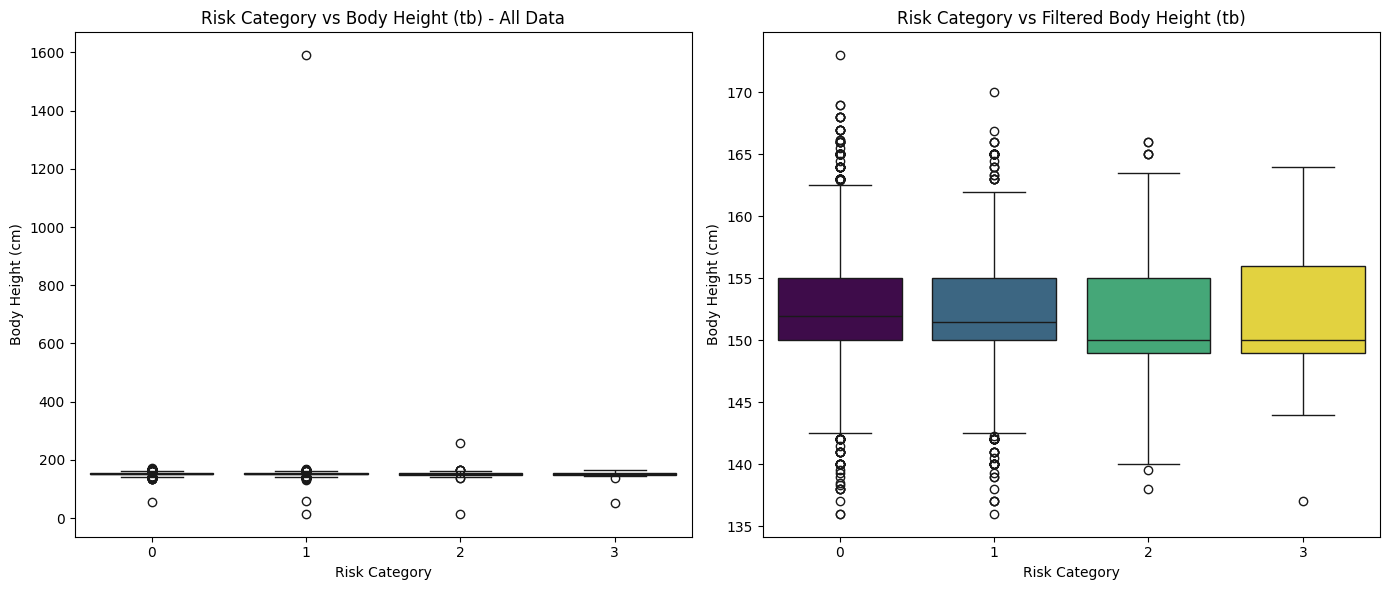

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(x="risiko_cat", y="tb", data=df, ax=axes[0], palette='viridis', hue="risiko_cat", legend=False)
axes[0].set_title('Risk Category vs Body Height (tb) - All Data')
axes[0].set_xlabel('Risk Category')
axes[0].set_ylabel('Body Height (cm)')

filtered_df = df[(df["tb"] < 180) & (df['tb'] > 135)]
sns.boxplot(x="risiko_cat", y="tb", data=filtered_df, ax=axes[1], palette='viridis', hue="risiko_cat", legend=False)
axes[1].set_title('Risk Category vs Filtered Body Height (tb)')
axes[1].set_xlabel('Risk Category')
axes[1].set_ylabel('Body Height (cm)')

plt.tight_layout()
plt.show()

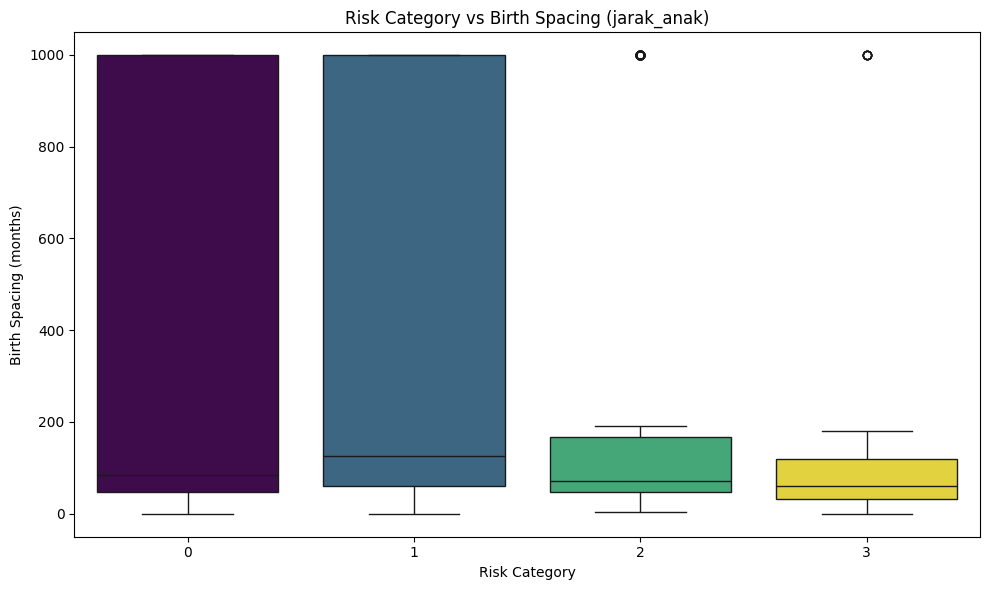

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x="risiko_cat", y="jarak_anak", data=df, ax=ax, palette='viridis', hue="risiko_cat", legend=False)
plt.title("Risk Category vs Birth Spacing (jarak_anak)")
plt.xlabel("Risk Category")
plt.ylabel("Birth Spacing (months)")
plt.tight_layout()
plt.show()

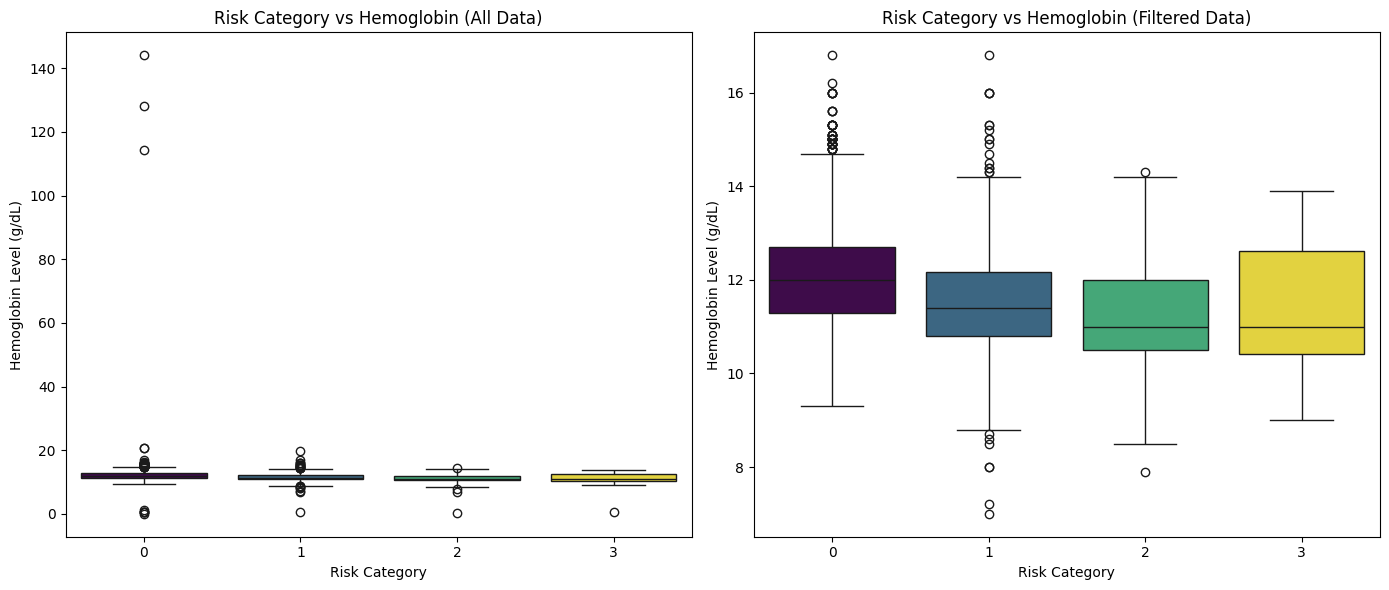

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# First box plot (all data)
sns.boxplot(x="risiko_cat", y="hb", data=df, ax=axes[0], palette='viridis', hue="risiko_cat", legend=False)
axes[0].set_title("Risk Category vs Hemoglobin (All Data)")
axes[0].set_xlabel("Risk Category")
axes[0].set_ylabel("Hemoglobin Level (g/dL)")

# Filtered data for the second box plot
filtered_df_hb = df[(df["hb"] < 18) & (df['hb'] >= 7)]
sns.boxplot(x="risiko_cat", y="hb", data=filtered_df_hb, ax=axes[1], palette='viridis', hue="risiko_cat", legend=False)
axes[1].set_title("Risk Category vs Hemoglobin (Filtered Data)")
axes[1].set_xlabel("Risk Category")
axes[1].set_ylabel("Hemoglobin Level (g/dL)")

plt.tight_layout()
plt.show()

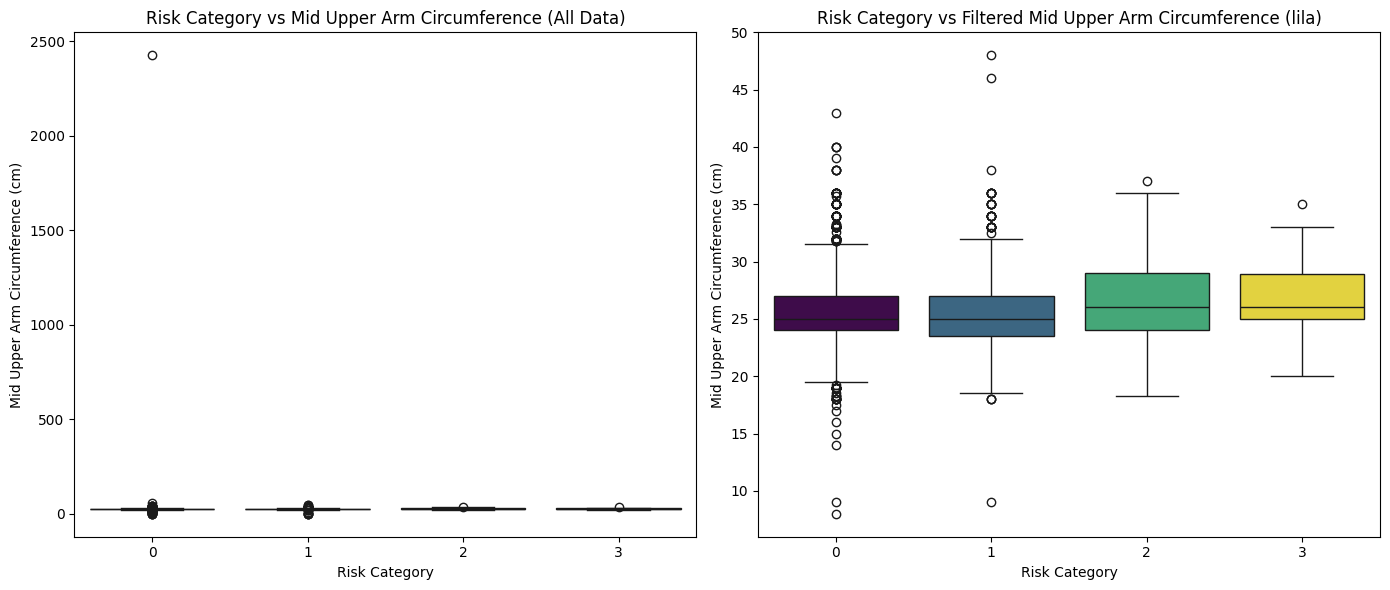

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# First box plot (all data)
sns.boxplot(x="risiko_cat", y="lila", data=df, ax=axes[0], palette='viridis', hue="risiko_cat", legend=False)
axes[0].set_title("Risk Category vs Mid Upper Arm Circumference (All Data)")
axes[0].set_xlabel("Risk Category")
axes[0].set_ylabel("Mid Upper Arm Circumference (cm)")

# Filtered data for the second box plot
filtered_df_lila = df[(df["lila"] < 50) & (df['lila'] >= 8)]
sns.boxplot(x="risiko_cat", y="lila", data=filtered_df_lila, ax=axes[1], palette='viridis', hue="risiko_cat", legend=False)
axes[1].set_title("Risk Category vs Filtered Mid Upper Arm Circumference (lila)")
axes[1].set_xlabel("Risk Category")
axes[1].set_ylabel("Mid Upper Arm Circumference (cm)")

plt.tight_layout()
plt.show()

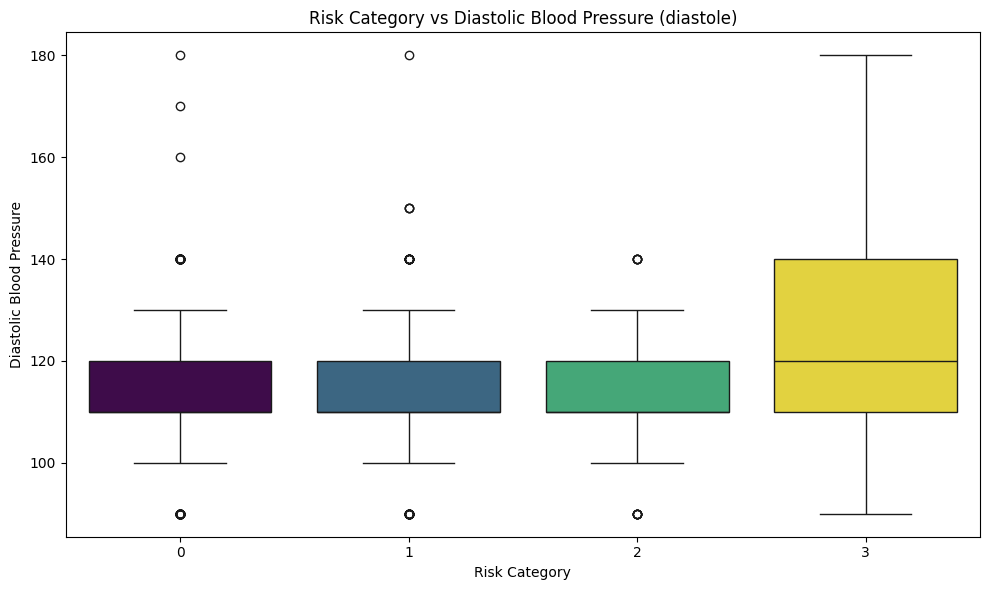

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x="risiko_cat", y="diastole", data=df, ax=ax, palette='viridis', hue="risiko_cat", legend=False)
plt.title("Risk Category vs Diastolic Blood Pressure (diastole)")
plt.xlabel("Risk Category")
plt.ylabel("Diastolic Blood Pressure")
plt.tight_layout()
plt.show()

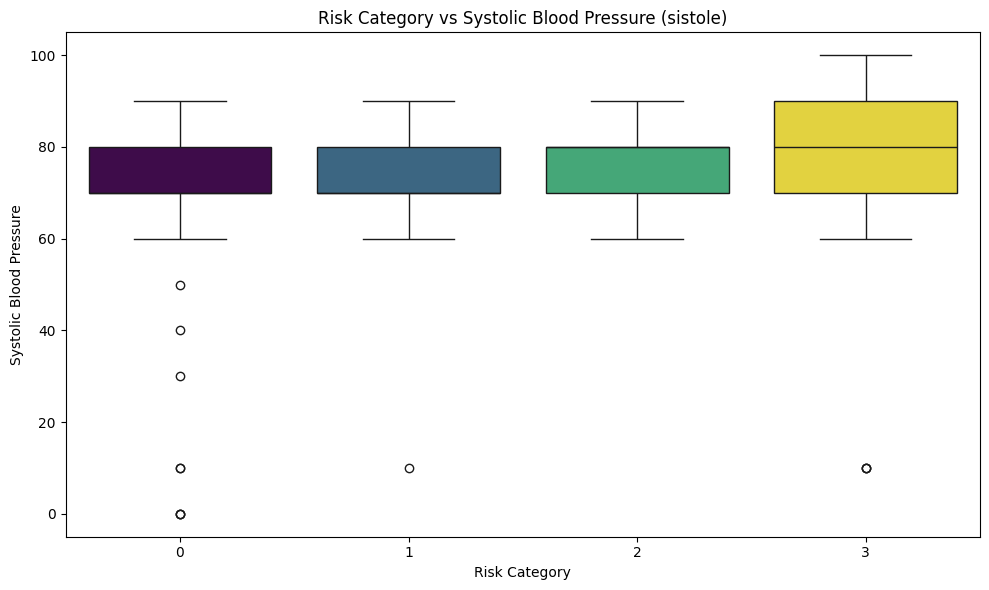

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x="risiko_cat", y="sistole", data=df, ax=ax, palette='viridis', hue="risiko_cat", legend=False)
plt.title("Risk Category vs Systolic Blood Pressure (sistole)")
plt.xlabel("Risk Category")
plt.ylabel("Systolic Blood Pressure")
plt.tight_layout()
plt.show()

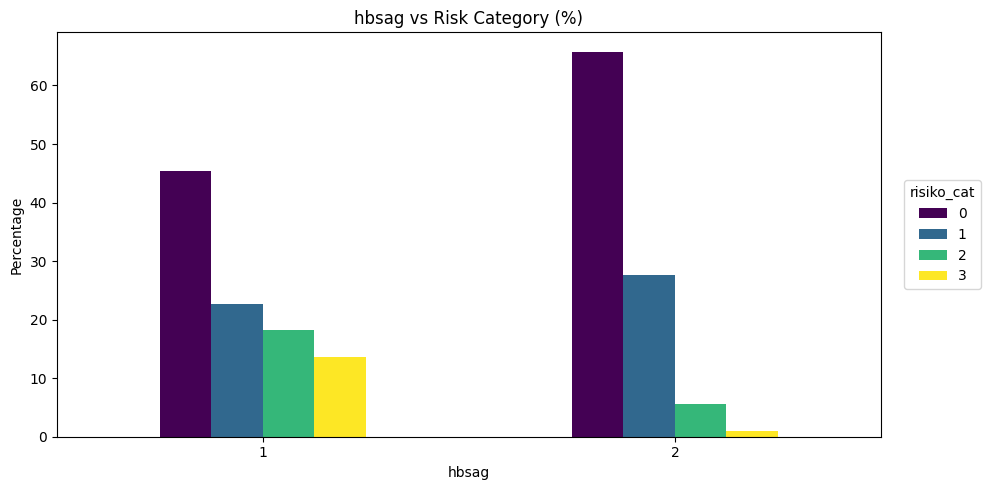

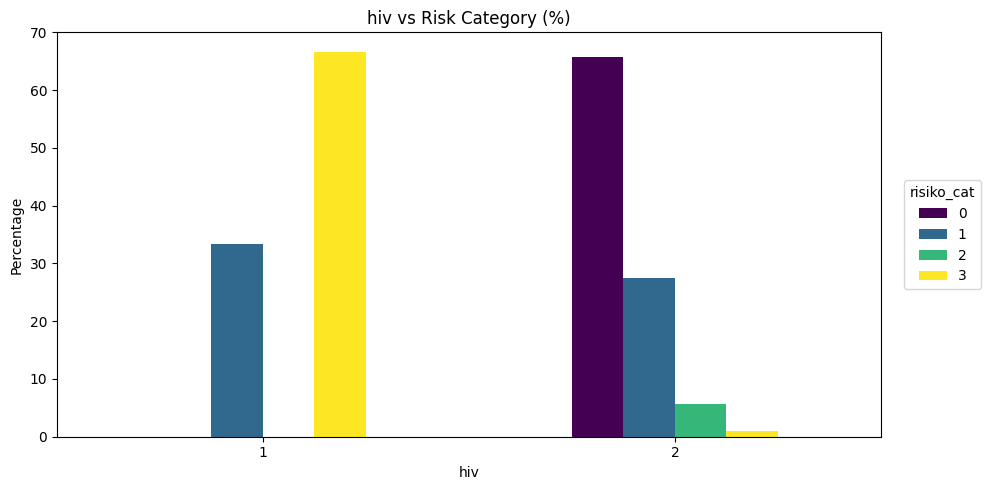

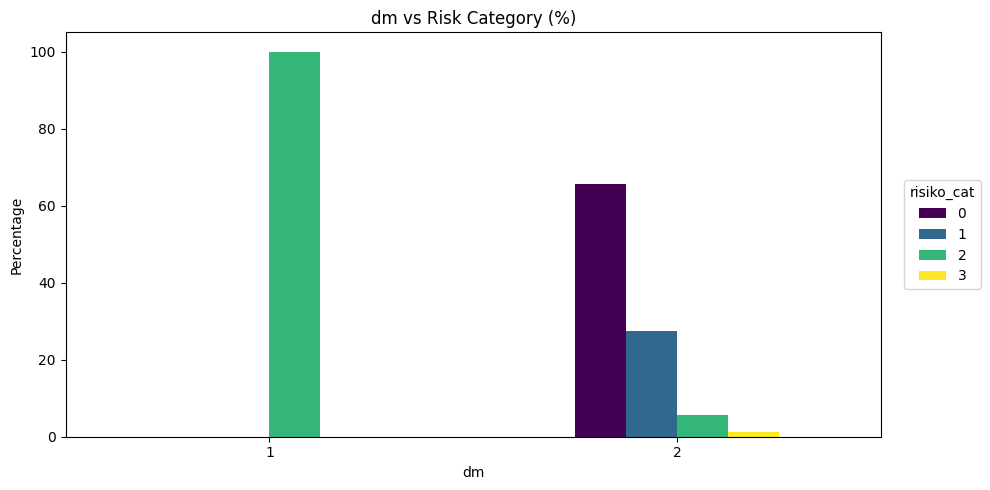

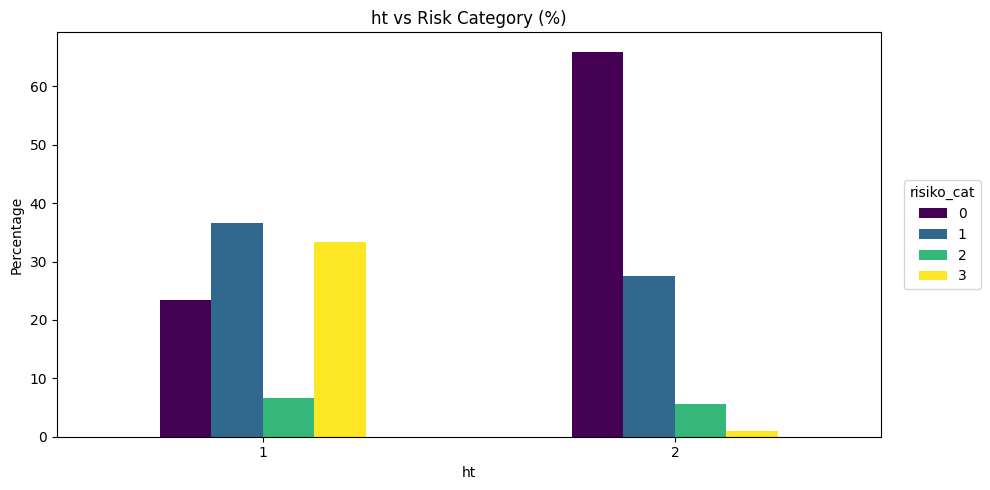

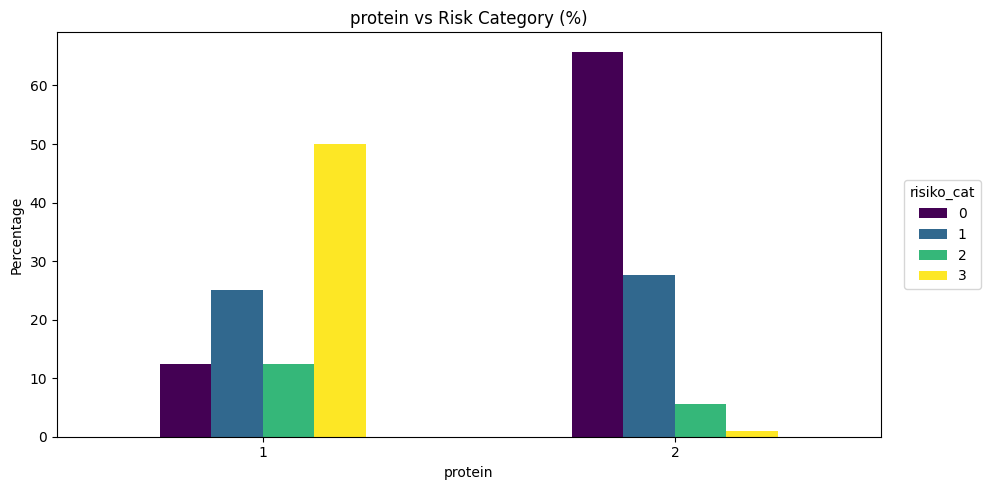

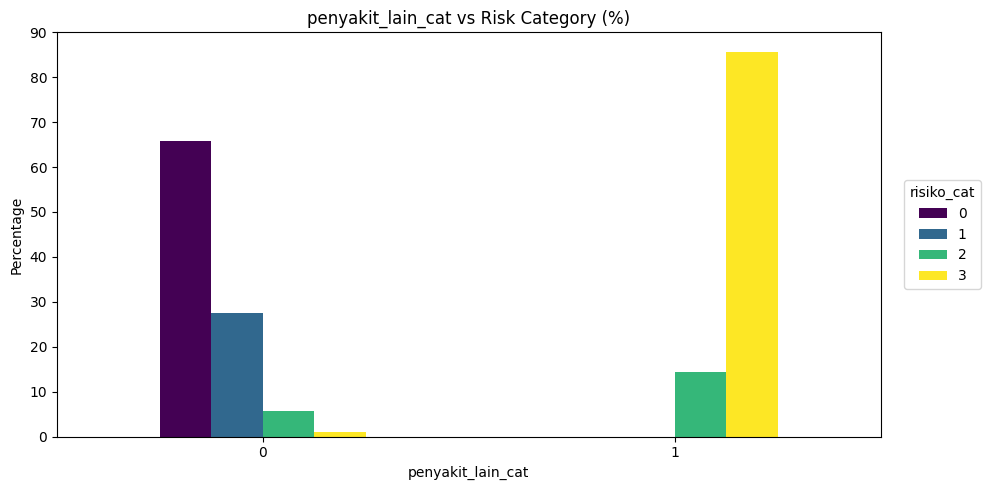

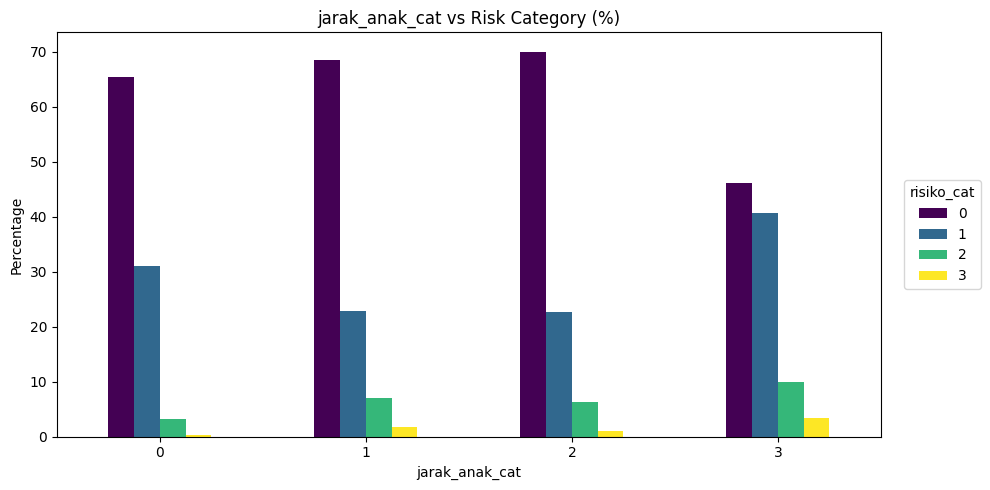

In [ ]:
for col in binary_cols + ['jarak_anak_cat']:
    ct = pd.crosstab(df[col], df['risiko_cat'], normalize='index') * 100
    ct.plot(kind='bar', figsize=(10, 5), colormap='viridis')
    plt.title(f"{col} vs Risk Category (%)")
    plt.ylabel("Percentage")
    plt.xticks(rotation=0)
    plt.legend(title='risiko_cat', bbox_to_anchor=(1.02, 0.5), loc='center left')
    plt.tight_layout()
    plt.show()

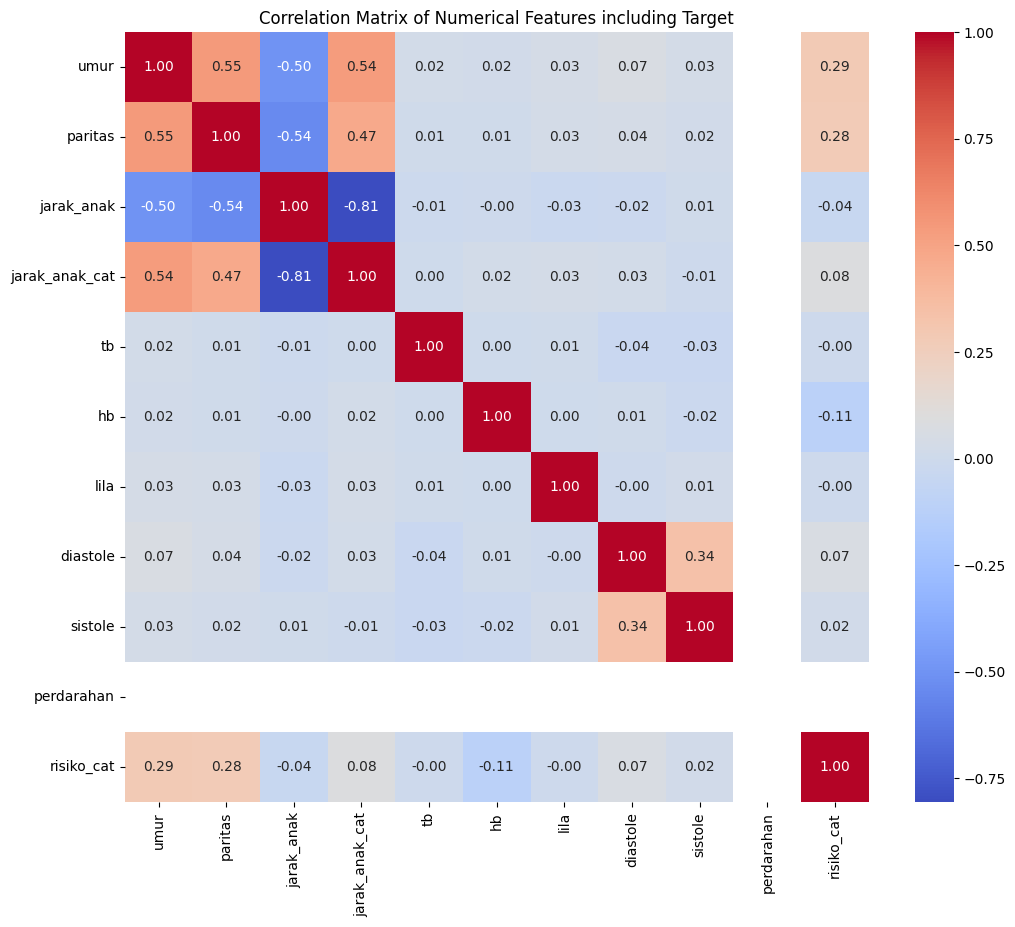

In [ ]:
plt.figure(figsize=(12, 10))
# Create a list of all relevant columns for the heatmap, including the target
heatmap_cols = numeric_cols + [terget]
sns.heatmap(df[heatmap_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features including Target')
plt.show()

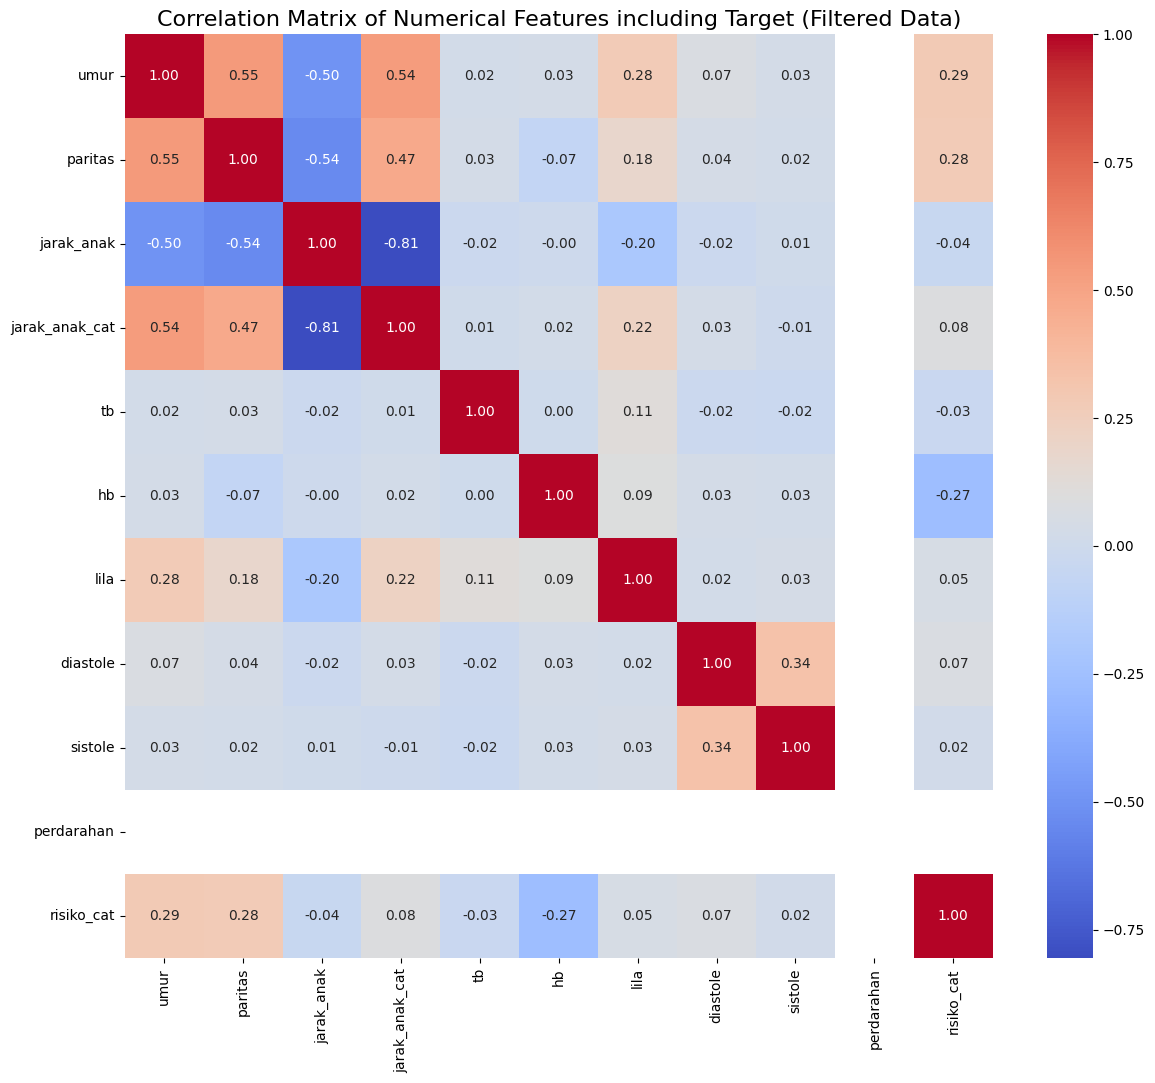

In [ ]:
plt.figure(figsize=(14, 12))

# Combine all filtering conditions from previous analysis
combined_filtered_df = df[
    (df["tb"] < 170) & (df['tb'] > 130) &
    (df["hb"] < 18) & (df['hb'] >= 7) &
    (df["lila"] < 50) & (df['lila'] >= 8)
]

# Define columns for heatmap including the target
# Assuming 'numeric_cols' and 'terget' are already defined in the session
heatmap_cols_filtered = numeric_cols + [terget]

sns.heatmap(combined_filtered_df[heatmap_cols_filtered].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features including Target (Filtered Data)', fontsize=16)
plt.show()

In [ ]:
df_filtered = combined_filtered_df.copy()
print(f"Shape of the filtered DataFrame: {df_filtered.shape}")
print("Head of the filtered DataFrame:")
df_filtered.head(3)

Shape of the filtered DataFrame: (5273, 17)
Head of the filtered DataFrame:


,umur,paritas,jarak_anak,jarak_anak_cat,tb,hb,lila,hbsag,hiv,dm,ht,protein,diastole,sistole,perdarahan,penyakit_lain_cat,risiko_cat
0,20,0,999.0,0,150.0,9.6,24.0,2,2,2,2,2,120,90,2,0,1
1,30,3,48.0,1,151.0,11.2,28.0,2,2,2,2,2,120,80,2,0,0
2,28,1,77.0,2,150.0,12.3,26.0,2,2,2,2,2,110,70,2,0,0


In [ ]:
df_filtered.to_csv('pregnancy_risk_filtered.csv', index=False)

The filtered dataset has been successfully saved to `pregnancy_risk_filtered.csv`.